In [1]:
# import built-in libraries
from pathlib import Path

# import third-party libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
data_path = Path("./projects/data/customer_churn.csv")
df = pd.read_csv(data_path)
df.head(3)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices


In [3]:
pd.set_option('display.max_rows', None)
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='str')

In [4]:
pd.concat([df.dtypes, df.isnull().sum()], axis=1).T

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,str,str,int64,str,int64,str,int64,float64,float64,int64,...,str,float64,float64,float64,int64,float64,float64,str,str,str
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3488,3488


In [5]:
# df[['Monthly Charge']].value_counts()

QA_1:What is the customer churn rate? Determine the total revenue lost from churning?  Determine the total revenue lost from churning? 


In [6]:
churn_rate = df['Customer Status'].value_counts(normalize=True).loc['Churned']
print("customer churn rate:", churn_rate)
total_revenue_churned = df.loc[df['Customer Status'] == 'Churned', 'Total Revenue'].sum()
print("total revenue from churned customers:", total_revenue_churned)


customer churn rate: 0.3348588863463005
total revenue from churned customers: 3641352.63


QA_2:Strellis bar chart. how the major reasons for churning using a 

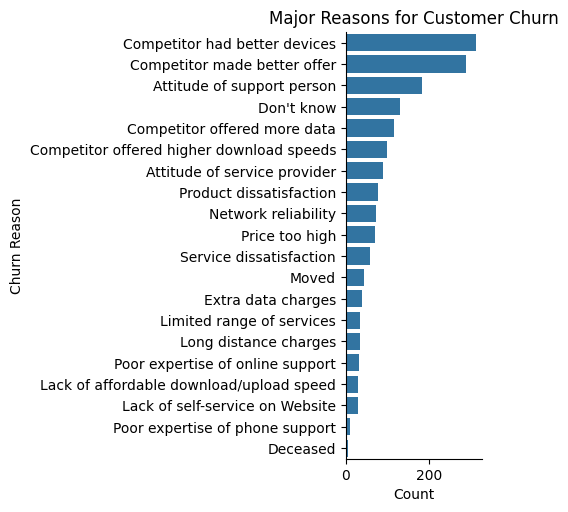

In [7]:
# df["Churn Reason"].value_counts().sort_values(ascending=False).plot.bar()
order = df.query("`Customer Status` == 'Churned'")["Churn Reason"].value_counts().index
sns.catplot(data=df.query("`Customer Status` == 'Churned'"), y="Churn Reason", kind="count", order=order )
plt.title("Major Reasons for Customer Churn")
plt.ylabel("Churn Reason")
plt.xlabel("Count")
plt.show()

QA_3:Discuss the distribution of customers that stayed and churned for the selected 
variables (total_charges, revenue, and tenure_in_months) using a histogram. 

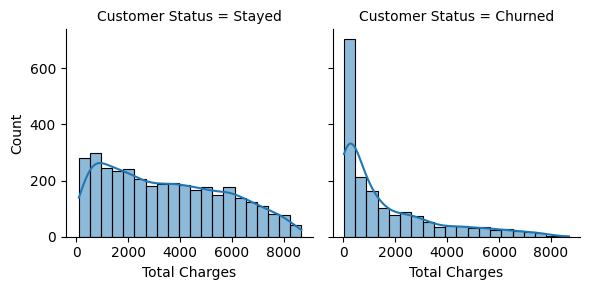

In [8]:
g =sns.FacetGrid(df, col="Customer Status",)
g.map(sns.histplot, "Total Charges", kde=True, bins=20)
plt.show()


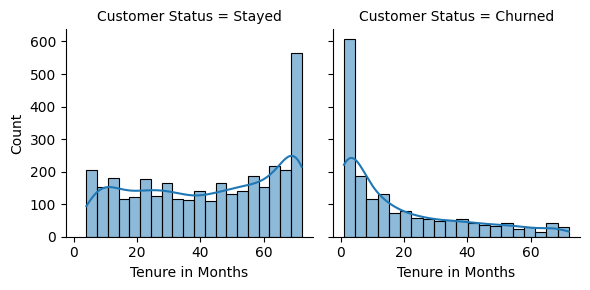

In [9]:
g =sns.FacetGrid(df, col="Customer Status")
g.map(sns.histplot, "Tenure in Months", kde=True, bins=20)
plt.show()

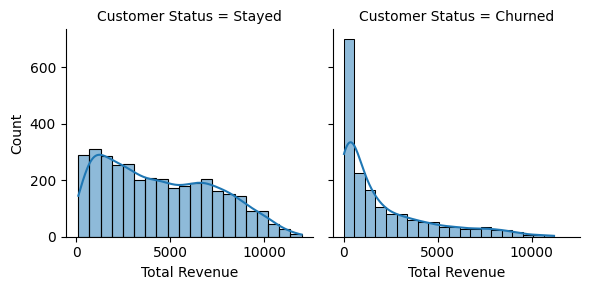

In [10]:
g =sns.FacetGrid(df, col="Customer Status")
g.map(sns.histplot, "Total Revenue", kde=True, bins=20)

The histograms show clear differences between stayed and churned customers.

- For Total Charges, churned customers are concentrated at lower values, while stayed customers have a wider distribution and more customers with high total charges. This suggests that customers who churned usually spent less overall.

- For Total Revenue, churned customers also tend to have lower total revenue compared with stayed customers. Stayed customers contribute more revenue because they usually remain with the company longer.

- For Tenure in Months, churned customers are mostly concentrated in shorter tenures, especially in the first months. Stayed customers have a broader distribution and many have much longer tenure. This indicates that customers with shorter tenure are more likely to churn.

QA_4:Complete the following using a pivot table. 
i. Determine the total revenue contribution from a Two-Year contract for each Offer by 
internet type. 
ii. For Offer B, what (%) of the total revenue was contributed by churned 
customers that accepted a Month-to-Month contract for Cable service. 

In [11]:
#i
pt= df.pivot_table(index=["Offer",], columns=["Contract","Internet Type"], values="Total Revenue", aggfunc="sum")
pt.loc[:,("Two Year",)]

Internet Type,Cable,DSL,Fiber Optic
Offer,,,
Offer A,349750.71,720759.09,1474862.52
Offer B,164188.21,362671.78,473681.65
Offer C,10360.26,34148.92,80196.94
Offer D,5443.22,5592.51,22464.25
Offer E,1684.86,3019.54,6134.10


In [12]:
#ii
pt = df.pivot_table(index=["Offer","Contract","Internet Type"], columns="Customer Status", values="Total Revenue", aggfunc="sum",fill_value=0)
# pt

In [13]:
num = pt.loc[("Offer B", "Month-to-Month", "Cable"),"Churned"]
num
denom = pt.loc["Offer B"].sum().sum()
denom
churn_rate_offer_b = num / denom *100
print(f"For Offer B, Month-to-Month, Cable: {churn_rate_offer_b:.2f}%")

For Offer B, Month-to-Month, Cable: 0.45%
